# Import Library

In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

In [2]:
# Library pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [3]:
# Library pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# mencetak tensorflow yang digunakan
print(tf.__version__)

2.20.0


# Data Loading

In [5]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadalifharahap","key":"481ae27993839cee1841a4015a4d477e"}'}

In [6]:
# Download kaggle dataset and unzip the file
!kaggle datasets download -d tolgadincer/labeled-chest-xray-images
!unzip labeled-chest-xray-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: chest_xray/train/NORMAL/NORMAL-2558319-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2558319-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2559035-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2559035-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2565226-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2568157-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2597757-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2597757-0002.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-263932-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2646645-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2646923-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2655558-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2659844-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2675017-0001.jpeg  
  inflating: chest_xray/train/NORMAL/NORMAL-2675017-00

### Data preparation

In [7]:
import os
import shutil

In [8]:
# Direktori awal train and test
train_dir = 'chest_xray/train'
test_dir = 'chest_xray/test'

# Direktori baru untuk dataset gabungan
combined_dir = 'chest_xray/dataset'

In [9]:
# Buat direktori baru unruk dataset gabungan
os.makedirs(combined_dir, exist_ok=True)

Penggabungan dataset dengan menyalin file serta folder dari direktori train dan test ke dalam direktori dataset yang dibuat sebelumnya.

In [10]:
# Salin file dan folder dari train
for category in os.listdir(train_dir):
  category_dir = os.path.join(train_dir, category)
  if os.path.isdir(category_dir):
    shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

# Salin file dan folder dari test
for category in os.listdir(test_dir):
  category_dir = os.path.join(test_dir, category)
  if os.path.isdir(category_dir):
    shutil.copytree(category_dir, os.path.join(combined_dir, category), dirs_exist_ok=True)

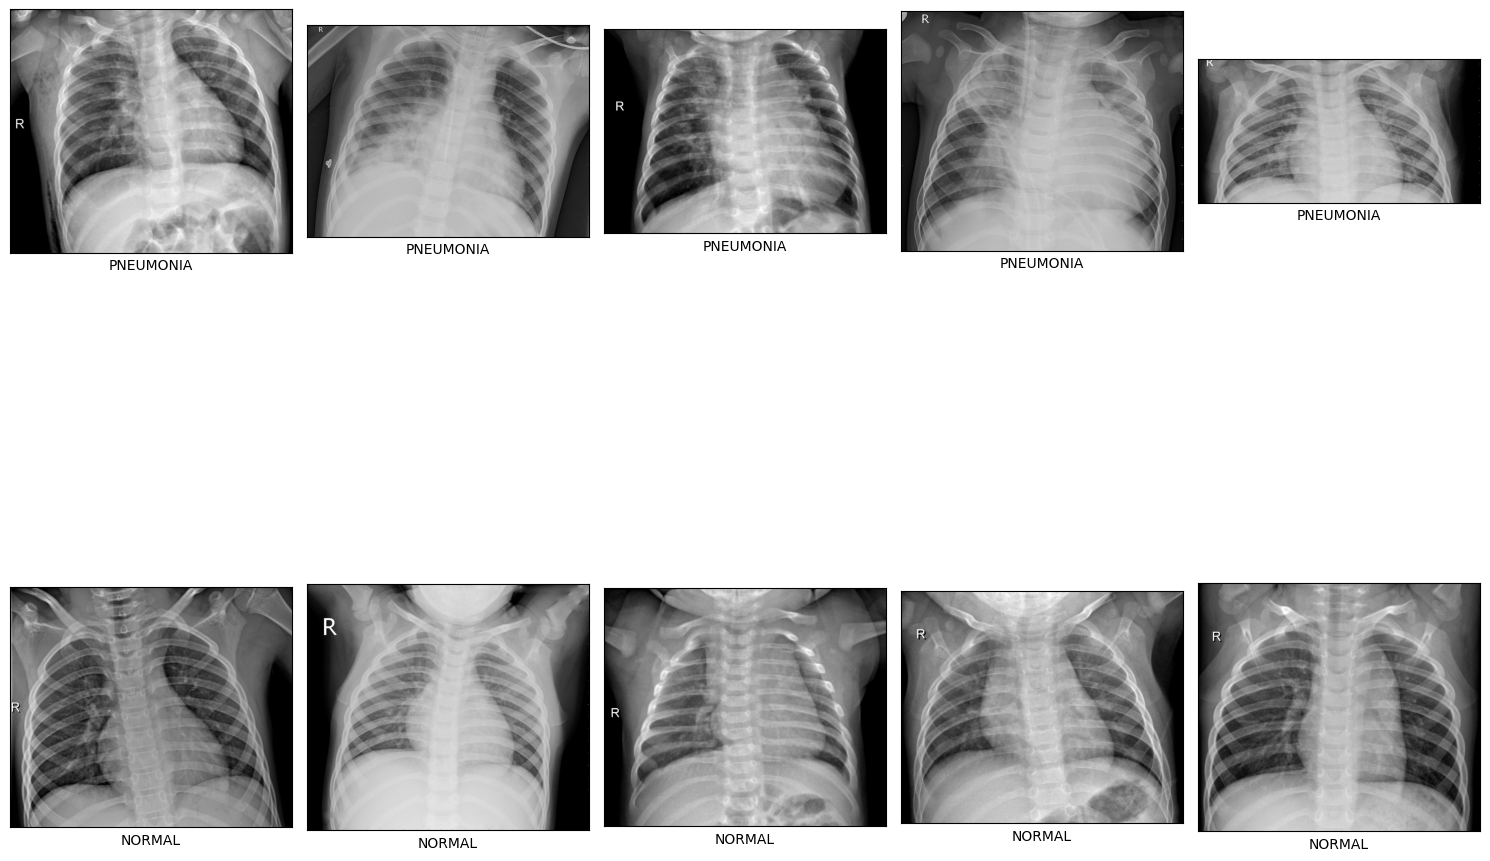

In [11]:
import matplotlib.pyplot as plt

# Membuat kamus yang menyimpan gambar untuk setiap kelas dalam data
lung_image = {}

# Tentukan path sumber train
path = 'chest_xray/'
path_sub = os.path.join(path, "dataset")
for i in os.listdir(path_sub):
  lung_image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan 5 gambar secara acak setiap 2 kelas dari data
path_sub = "chest_xray/dataset/"

# Menampilkan secara acak 5 gambar kelas dari data latih
fig, axs = plt.subplots(len(lung_image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
  images = np.random.choice(lung_image[class_name], 5, replace=False)

  for j, image_name in enumerate(images):
    img_path = os.path.join(path_sub, class_name, image_name)
    img = Image.open(img_path).convert("L")
    axs[i, j].imshow(img, cmap='gray')
    axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

### Plot Distribusi

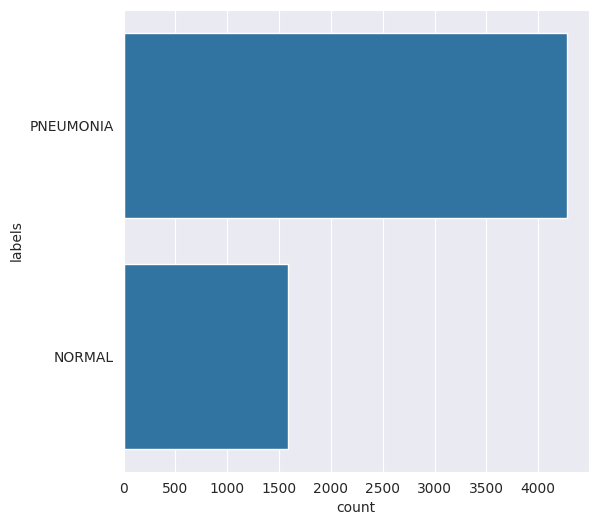

In [12]:
import seaborn as sns

lung_path = "chest_xray/dataset/"

# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

# Dapatkan nama file gambar, path file, dan label satu per satu dengan loopinh, dan simpan sebagai dataset
for path, subdirs, files in os.walk(lung_path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split('/')[-1])
    file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6, 6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# Data Augmentation

In [13]:
# Fungsi rotasi berlawanan arah jarum jam
def anticlockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  sudut = random.randint(0, 100)
  return rotate(img, sudut)

# Fungsi rotasi searah jarum jam
def clockwise_rotation(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  sudut = random.randint(0, 100)
  return rotate(img, -sudut)

# Fungsi membalik gambar secara vertikal
def flip_up_down(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  return np.flipud(img)

# Membuat fungsi untuk memberikan efek peningkatan kecerahan
def add_brightness(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  img = adjust_gamma(img, gamma=0.5, gain=1)
  return img

# Membuat fungsi efek blur
def blur_image(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  return cv2.GaussianBlur(img, (9, 9), 0)

# Membuat fungsi memberikan efek pergeseran
def sheared(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 244))
  transform = AffineTransform(shear=0.2)
  shear_image = warp(img, transform, mode="wrap")
  return shear_image

# Membuat fungsi melakukan pergeseran melengkung
def warp_shift(img):
  img = cv2.cvtColor(img, 0)
  img = cv2.resize(img, (224, 224))
  transform = AffineTransform(translation=(0, 40))
  warp_image = warp(img, transform, mode="wrap")
  return warp_image

Selanjutnya augmentasi dilakukan pada gambar-gambar normal dalam dataset. Pertama, kita mendefinisikan berbagai transformasi yang akan diterapkan, seperti rotasi, pergeseran, blur, dan lainnya. Kemudian, kita membaca nama-nama gambar dari folder yang berisi gambar-gambar normal.

Selanjutnya, kita menghasilkan gambar-gambar baru dengan menerapkan transformasi acak pada setiap gambar asli. Proses ini dilakukan hingga jumlah gambar yang dihasilkan mencapai target. Hasil dari augmentasi ini akan membantu memperluas dataset dengan variasi lebih banyak, yang dapat digunakan untuk melatih model lebih baik.

In [14]:
# Membuat variabel transformasi menyimpan proses yang telah dibangun sebelumnya
transformations = { 'rotate anticlockwise': anticlockwise_rotation,
                    'rotate clockwise': clockwise_rotation,
                    'warp shift': warp_shift,
                    'blurring image': blur_image,
                    'add brightness' : add_brightness,
                    'flip up down': flip_up_down,
                    'shear image': sheared
                    }

images_path="chest_xray/dataset/NORMAL" # Path untuk gambar asli
augmented_path="chest_xray/dataset/NORMAL_augmented" # Path untuk gambar yang sudah diaugmentasi
images=[] # Penyimpanan gambar yang telah melalui pra-pemrosesan

# Baca nama gambar dari folder dan tambahkan path ke dalam array "images"
for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

# Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
# Variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
images_to_generate=2000
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0      # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
        transformation_count = random.randint(1, len(transformations)) # Pilih jumlah transformasi acak yang akan diterapkan pada gambar

        while n <= transformation_count:
            key = random.choice(list(transformations)) # Secara acak memilih dan memanggil metode
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)  # Mengonversi gambar ke format byte yang tidak ditandatangani, dengan nilai dalam [0, 255]
        cv2.imwrite(new_image_path, transformed_image)  # Simpan hasil transformasi augmentasi pada gambar ke path yang ditentukan
        i =i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')

In [15]:
images_path="chest_xray/dataset/NORMAL"
augmented_path="chest_xray/dataset/NORMAL_augmented"

os.makedirs(augmented_path, exist_ok=True)  # TAMBAH

images=[]

for im in os.listdir(images_path):
    images.append(os.path.join(images_path,im))

images_to_generate=2000
i=1

while i<=images_to_generate:
    image=random.choice(images)
    try:
        original_image = io.imread(image)
        transformed_image=None
        n = 0
        transformation_count = random.randint(1, len(transformations))

        while n <= transformation_count:
            key = random.choice(list(transformations))
            transformed_image = transformations[key](original_image)
            n = n + 1

        new_image_path= "%s/augmented_image_%s.jpg" %(augmented_path, i)
        transformed_image = img_as_ubyte(transformed_image)
        cv2.imwrite(new_image_path, transformed_image)
        print(f"Saved: {i}")  # TAMBAH
        i = i+1
    except ValueError as e:
        print('could not read the',image ,':',e,'hence skipping it.')
    except Exception as e:  # TAMBAH
        print('Error:', e)  # TAMBAH
        i = i + 1  # TAMBAH

Saved: 1
Saved: 2
Saved: 3
Saved: 4
Saved: 5
Saved: 6
Saved: 7
Saved: 8
Saved: 9
Saved: 10
Saved: 11
Saved: 12
Saved: 13
Saved: 14
Saved: 15
Saved: 16
Saved: 17
Saved: 18
Saved: 19
Saved: 20
Saved: 21
Saved: 22
Saved: 23
Saved: 24
Saved: 25
Saved: 26
Saved: 27
Saved: 28
Saved: 29
Saved: 30
Saved: 31
Saved: 32
Saved: 33
Saved: 34
Saved: 35
Saved: 36
Saved: 37
Saved: 38
Saved: 39
Saved: 40
Saved: 41
Saved: 42
Saved: 43
Saved: 44
Saved: 45
Saved: 46
Saved: 47
Saved: 48
Saved: 49
Saved: 50
Saved: 51
Saved: 52
Saved: 53
Saved: 54
Saved: 55
Saved: 56
Saved: 57
Saved: 58
Saved: 59
Saved: 60
Saved: 61
Saved: 62
Saved: 63
Saved: 64
Saved: 65
Saved: 66
Saved: 67
Saved: 68
Saved: 69
Saved: 70
Saved: 71
Saved: 72
Saved: 73
Saved: 74
Saved: 75
Saved: 76
Saved: 77
Saved: 78
Saved: 79
Saved: 80
Saved: 81
Saved: 82
Saved: 83
Saved: 84
Saved: 85
Saved: 86
Saved: 87
Saved: 88
Saved: 89
Saved: 90
Saved: 91
Saved: 92
Saved: 93
Saved: 94
Saved: 95
Saved: 96
Saved: 97
Saved: 98
Saved: 99
Saved: 100
Saved: 1

labels
PNEUMONIA    4273
NORMAL       3583
Name: count, dtype: int64


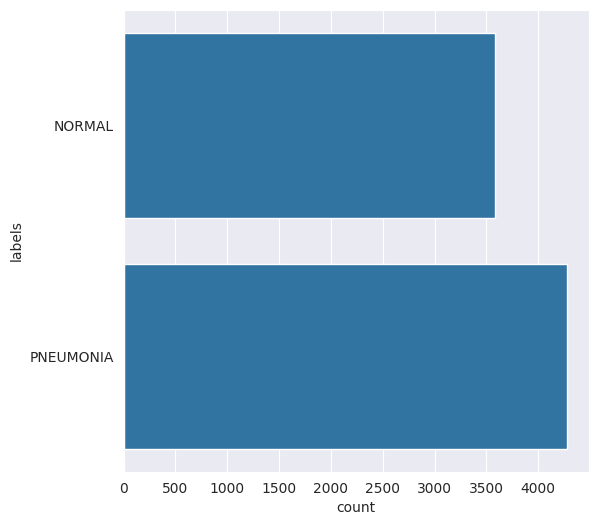

In [16]:
# Definisikan path sumber
lung_path = "chest_xray/dataset/"

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(lung_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        label = path.split('/')[-1]
        label = 'NORMAL' if 'NORMAL' in label else label  # TAMBAH ini
        labels.append(label)
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

print(distribution_train['labels'].value_counts())

Label = distribution_train['labels']
plt.figure(figsize=(6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

# Data Splitting

langkah selanjutnya adalah membagi data menjadi set pelatihan (training set) dan set pengujian (test set).

In [18]:
# Panggil variabel mypath yang menampung folder dataset gambar
mypath= 'chest_xray/dataset/'

file_name = []
labels = []
full_path = []
for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        label = path.split('/')[-1]
        label = 'NORMAL' if 'NORMAL' in label else label  # ← tambahkan ini
        labels.append(label)
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah dataframe agar rapi
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
# Melihat jumlah data gambar pada masing-masing label
df.groupby(['labels']).size()

,0
labels,
NORMAL,3583
PNEUMONIA,4273


Kode di atas digunakan untuk mengumpulkan informasi tentang gambar-gambar dalam dataset. Pertama, kita mendefinisikan variabel mypath yang menunjukkan folder dataset gambar. Selanjutnya, kita melakukan iterasi melalui semua file dalam folder tersebut, serta mengumpulkan informasi, seperti nama file, path lengkap, dan label dari setiap gambar pada beberapa list.

Kemudian, kita menggunakan list tersebut untuk membuat dataframe yang rapi. Dataframe ini memudahkan kita untuk melihat jumlah data gambar pada setiap label. Dengan menggunakan groupby dan size, kita dapat melihat seberapa seimbang distribusi data dalam dataset berdasarkan label-label yang ada.

In [20]:
# Variabel yang digunakan pada pemisahan data ini di mana variabel x = data path dan y = data labels

X= df['path']
y= df['labels']

# Split dataset awal menjadi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=300)

Selanjutnya, kita membagi dataset awal menjadi dua bagian, yaitu data pelatihan (train) dan data uji (test). Proses ini dilakukan dengan menggunakan fungsi train_test_split dari library scikit-learn. Data uji akan menyimpan 20% dari total data, sedangkan data pelatihan akan menyimpan 80% sisanya. Penggunaan random_state untuk memastikan bahwa hasil pemisahan data ini dapat direproduksi secara konsisten.

In [21]:
# Menyatukan ke dalam masing-masing dataframe
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [22]:
# Gabungkan DataFrame df_tr dan df_te
df_all = pd.concat([df_tr, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

# Cek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambar yang sesuai dengan labelnya
datasource_path = "chest_xray/dataset/"
# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "Dataset-Final/"


set    labels   
test   NORMAL        722
       PNEUMONIA     850
train  NORMAL       2861
       PNEUMONIA    3423
dtype: int64 


                                                   path     labels    set
5587  chest_xray/dataset/PNEUMONIA/VIRUS-6121529-000...  PNEUMONIA  train
6231  chest_xray/dataset/NORMAL/NORMAL-2256620-0001....     NORMAL  train
143   chest_xray/dataset/NORMAL_augmented/augmented_...     NORMAL  train
5702  chest_xray/dataset/PNEUMONIA/BACTERIA-6823523-...  PNEUMONIA  train
4022  chest_xray/dataset/NORMAL/NORMAL-7323530-0001....     NORMAL  train


Pada tahap ini, kita telah menggabungkan data training dan testing dalam satu DataFrame untuk mempermudah pengelolaan serta analisis. Selanjutnya, kita mencetak distribusi data untuk memastikan bahwa pembagian data telah dilakukan dengan benar. Setelah itu, kita mengatur variabel path untuk dataset asli dan dataset yang sudah dibagi, yang akan digunakan pada tahap pemrosesan berikutnya.

In [23]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    # Buat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    # Tentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    # Salin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

# Image Data Generator

In [24]:
# Definisikan direktori training dan test
TRAIN_DIR = "Dataset-Final/train/"
TEST_DIR = "Dataset-Final/test/"

train_normal = os.path.join(TRAIN_DIR + '/NORMAL')
train_pneumonia = os.path.join(TRAIN_DIR + '/PNEUMONIA')
test_normal = os.path.join(TEST_DIR + '/NORMAL')
test_pneumonia = os.path.join(TEST_DIR + '/PNEUMONIA')

print("Total number of normal images in training set: ",len(os.listdir(train_normal)))
print("Total number of pneumonic images in training set: ",len(os.listdir(train_pneumonia)))
print("Total number of normal images in test set: ",len(os.listdir(test_normal)))
print("Total number of pneumonic images in test set: ",len(os.listdir(test_pneumonia)))

Total number of normal images in training set:  2861
Total number of pneumonic images in training set:  3423
Total number of normal images in test set:  722
Total number of pneumonic images in test set:  850


In [25]:
# Buat objek ImageDataGenerator yang menormalkan gambar
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="grayscale",
                                              class_mode='binary',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                color_mode="grayscale",
                                                   class_mode='binary',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="grayscale",
                                                  class_mode='binary',
                                                  shuffle=False)

Found 5028 images belonging to 2 classes.
Found 1256 images belonging to 2 classes.
Found 1572 images belonging to 2 classes.


# Pembangunan Model dengan skema parameter tuning

### CNN Arsitektur

In [26]:
####################### Init sequential model ##################################
model_1 = Sequential()

# ######################### Input layer with Fully Connected Layer ################################
# 1st Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(150,150,1)))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 2nd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (4, 4),padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# 3rd Convolutional layer, Batch Normalization layer, and Pooling layer
model_1.add(Conv2D(32, (7, 7), padding='same', activation='relu'))
model_1.add(BatchNormalization())
model_1.add(MaxPool2D((2, 2)))

# Flatten layer
model_1.add(Flatten())
# 1nd Dense Layer
model_1.add(Dense(128, activation = 'relu'))
# 1nd Dropout Layer
model_1.add(Dropout(0.5))
# 2nd Dense Layer
model_1.add(Dense(64, activation = 'relu'))
# 2nd Dropout Layer
model_1.add(Dropout(0.3))

# Final Dense layer => For output prediction 1 mean (binary class in dataset), sigmoid for binary cases
model_1.add(Dense(1, activation='sigmoid'))
######################### Fully Connected Layer ################################

######################### Compile Model ################################
model_1.compile(optimizer=tf.keras.optimizers.RMSprop(),
                loss='binary_crossentropy',
                metrics=['accuracy'])

# Summary of the Model Architecture
print(model_1.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 32)     │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,402,881 (5.35 MB)

 Trainable params: 1,402,689 (5.35 MB)

 Non-trainable params: 192 (768.00 B)

None


In [27]:
count_normal, count_pneumonia = len(os.listdir(train_normal)), len(os.listdir(train_pneumonia))
weight_0 = (1 / count_normal) * (count_normal + count_pneumonia) / 2.0
weight_1 = (1 / count_pneumonia) * (count_pneumonia + count_normal) / 2.0

class_weights = {0 : weight_0, 1 : weight_1}

%time

# Fitting / training model
history_1 = model_1.fit(train_generator,
                        epochs=30,
                        batch_size=32,
                        validation_data=validation_generator,
                        class_weight = class_weights)

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 5.01 µs
Epoch 1/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 48s 248ms/step - accuracy: 0.8325 - loss: 0.7326 - val_accuracy: 0.5446 - val_loss: 5.4145
Epoch 2/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9202 - loss: 0.2973 - val_accuracy: 0.6019 - val_loss: 1.4411
Epoch 3/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9379 - loss: 0.2149 - val_accuracy: 0.5446 - val_loss: 7.1985
Epoch 4/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - accuracy: 0.9527 - loss: 0.1468 - val_accuracy: 0.9538 - val_loss: 0.1398
Epoch 5/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 32s 199ms/step - accuracy: 0.9576 - loss: 0.1303 - val_accuracy: 0.9403 - val_loss: 0.1798
Epoch 6/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 31s 199ms/step - accuracy: 0.9686 - loss: 0.1005 - val_accuracy: 0.9546 - val_loss: 0.1409
Epoch 7/30
158/158 ━━━━━━━━━━━━━━━━━━━━ 32s 200ms/step - accuracy: 0.9730 - loss: 0.0807 - val_accuracy: 0.9482 - val_loss: 0.1366
Epoch 8/30
158/158 

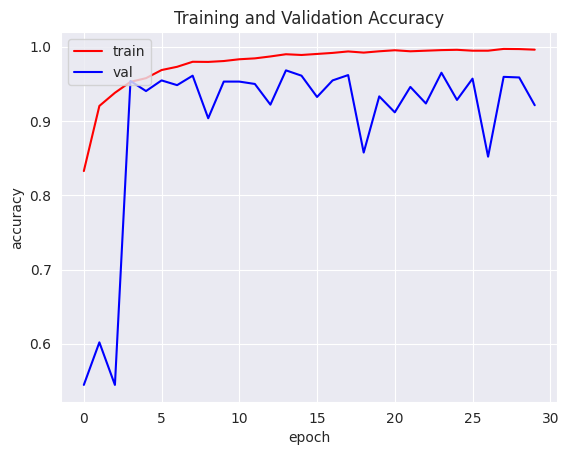

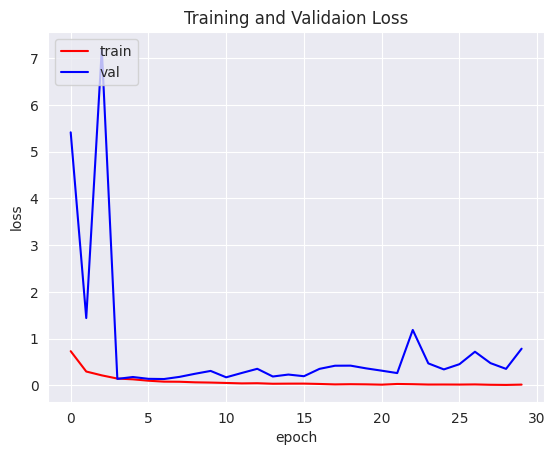

In [28]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()



              precision    recall  f1-score   support

      Normal     0.9794    0.9211    0.9493       722
   Pneumonia     0.9362    0.9835    0.9593       850

    accuracy                         0.9548      1572
   macro avg     0.9578    0.9523    0.9543      1572
weighted avg     0.9560    0.9548    0.9547      1572



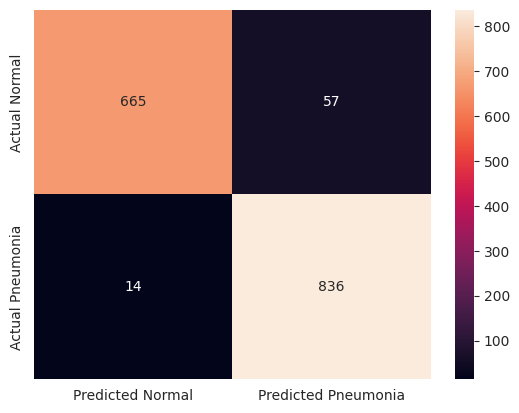

In [29]:
test_generator.reset()

preds_1 = model_1.predict(test_generator,verbose=0)
preds_1 = preds_1.copy()
preds_1[preds_1 <= 0.5] = 0
preds_1[preds_1 > 0.5] = 1

# Print Confusion Matrix
cm = pd.DataFrame(data=confusion_matrix(test_generator.classes, preds_1, labels=[0, 1]),index=["Actual Normal", "Actual Pneumonia"],
columns=["Predicted Normal", "Predicted Pneumonia"])
sns.heatmap(cm,annot=True,fmt="d")

# Print Classification Report
print("\n")
print(classification_report(y_true=test_generator.classes,y_pred=preds_1,target_names =['Normal','Pneumonia'], digits=4))

In [5]:
import json

with open('Latihan_Klasifikasi_Gambar.ipynb', 'r', encoding='utf-8') as f:
    nb = json.load(f)

# Hapus hanya metadata widgets, bukan output
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

with open('Latihan_Klasifikasi_Gambar.ipynb', 'w', encoding='utf-8') as f:
    json.dump(nb, f, indent=1)

print("Done!")

Done!
